# Quantum Intrusion Detection System (QIDS) - Data Preprocessing
---
#### Εισαγωγή & Φόρτωση Δεδομένων

Αυτό το notebook αποτελεί το κύριο περιβάλλον προετοιμασίας του συνόλου δεδομένων NSL-KDD, το οποίο θα χρησιμοποιηθεί στα πλαίσια της πτυχιακής εργασίας για την εκπαίδευση κβαντικών αλγορίθμων.

Αρχικά, φορτώνουμε τα ακατέργαστα δεδομένα (.txt) και ορίζουμε τα ονόματα των στηλών. Στη συνέχεια, για λόγους ευκολίας και μελλοντικής ταχύτητας, αποθηκεύουμε ένα αντίγραφο σε μορφή .csv. Αν και η ανάλυσή μας θα βασιστεί απευθείας στα DataFrames (εσωτερική μνήμη), το αρχείο αυτό θα διευκολύνει την οπτική επισκόπηση των δεδομένων.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import TargetEncoder
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Αν ο τρέχων φάκελος είναι ο 'notebooks', πήγαινε έναν φάκελο πίσω (στο root)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Τρέχων φάκελος εργασίας: {os.getcwd()}")


Τρέχων φάκελος εργασίας: /home/aggelos/Documents/projects/Quantum-IDS-NSLKDD


__Ορισμός των ονομάτων στηλών, καθώς το αρχικό dataset δεν περιέχει headers__

In [3]:
col_names = [
'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

__Φόρτωση του dataset__

In [4]:
df = pd.read_csv('data/KDDTrain+_20Percent.txt', sep=',', names=col_names)
print(f"Διαστάσεις αρχικού dataset: {df.shape}")
display(df.head()) 

Διαστάσεις αρχικού dataset: (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


__Αποθήκευση σε μορφή CSV για ευκολότερη μελλοντική πρόσβαση__

In [5]:
file_path = 'data/KDDTrain+_20Percent.csv'

if not os.path.exists(file_path):
    df.to_csv(file_path, index=False)
    print(f"Το dataset αποθηκεύτηκε επιτυχώς στο: {file_path}")
else:

    print(f"Το αρχείο {file_path} υπάρχει ήδη. Παράλειψη αποθήκευσης.")

Το αρχείο data/KDDTrain+_20Percent.csv υπάρχει ήδη. Παράλειψη αποθήκευσης.


## 1. Διαχωρισμός και Κανονικοποίηση Δεδομένων (Data Splitting & Normalization)
---
__Στρατηγικός Διαχωρισμός (Stratified Split)__ :
    Για την αξιολόγηση του μοντέλου, είναι απαραίτητος ο διαχωρισμός του dataset σε σύνολα εκπαίδευσης (Train set) και δοκιμής (Test set). Προκειμένου ο διαχωρισμός να είναι "δίκαιος" και αντιπροσωπευτικός, θα εφαρμόσουμε τεχνικές διαστρωμάτωσης (stratification). Αυτό διασφαλίζει ότι κρίσιμα χαρακτηριστικά διατηρούν την ίδια κατανομή και στα δύο υποσύνολα, αποτρέποντας το μοντέλο από το να αγνοήσει σπάνιες επιθέσεις.

__Κανονικοποίηση (Normalization)__ :
    Τα χαρακτηριστικά του δικτύου έχουν τελείως διαφορετικές κλίμακες μέτρησης (π.χ. bytes έναντι ποσοστιαίων ρυθμών). Είναι κρίσιμο να κανονικοποιήσουμε αυτές τις πληροφορίες σε μια κοινή κλίμακα, ώστε να είναι συγκρίσιμες και να μπορούν να τροφοδοτηθούν αποδοτικά στα κβαντικά κυκλώματα (Qubits).

#### Εξαγωγή Χαρακτηριστικών: Κατηγοριοποίηση του Μεγέθους Πακέτου (src_bytes_cat)

Για έναν ορθό διαστρωματωμένο διαχωρισμό, επιλέγουμε δύο βασικούς άξονες:
1. __Ετικέτα Κίνησης (Label)__ : Η βασικότερη μετρική, καθώς καθορίζει τη φύση της κίνησης (κανονική ή επίθεση).
2. __Μέγεθος Πακέτου (Source Bytes)__: Αν και σπάνια χρησιμοποιείται ως κύριο κριτήριο διαχωρισμού, παρέχει ζωτική πληροφορία για τη φυσική υπόσταση του πακέτου. Επειδή το μέγεθος των πακέτων παρουσιάζει τεράστια διασπορά, θα το κατηγοριοποιήσουμε σε ομάδες (bins).

Με αυτόν τον τρόπο, ετικετοποιούμε τα πακέτα ως low, medium, ή high ανάλογα με τον όγκο δεδομένων τους. Αυτό εξασφαλίζει ότι το μοντέλο μας θα εκπαιδευτεί και θα δοκιμαστεί σε πανομοιότυπες συνθήκες δικτυακής κίνησης.

Βήματα που ακολουθούν:
- Δημιουργία της νέας κατηγορικής μεταβλητής μεγέθους.
- Εφαρμογή του διαχωρισμού (Train/Test) διατηρώντας την κατανομή.

#### Χωρισμός του src_bytes σε 3 ισοπληθή διαστήματα (quantiles)

In [6]:
df['src_bytes_cat'] = pd.qcut(df['src_bytes'], q=4, duplicates='drop', labels=['low', 'medium', 'high'])

print("Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:")
print(df['src_bytes_cat'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:
src_bytes_cat
low       50.94%
high      24.96%
medium    24.09%
Name: proportion, dtype: str


#### Έλεγχος των ορίων κάθε κατηγορίας

In [7]:
check_bins = df.groupby('src_bytes_cat', observed=True)['src_bytes'].agg(['min', 'max', 'count'])
print("\nΌρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:")
display(check_bins)


Όρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:


,min,max,count
src_bytes_cat,,,
low,0,44,12834
medium,45,279,6069
high,280,381709090,6289


#### Δημιουργία σύνθετης βοηθητικής στήλης για τον διαστρωματωμένο διαχωρισμό (Label + Size Category)

In [8]:
df['strat_col'] = df['label'].astype(str) + "_" + df['src_bytes_cat'].astype(str)

#### Εντοπισμός συνδυασμών που εμφανίζονται λιγότερο από 2 φορές (αδύνατο να χωριστούν σε train/test)

In [9]:
counts = df['strat_col'].value_counts()
problematic_combinations = counts[counts < 2].index

print(f"Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: {len(problematic_combinations)}")

Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: 12


#### Αντιμετώπιση: Για τους σπάνιους συνδυασμούς, κρατάμε μόνο το βασικό Label παραλείποντας το μέγεθος

In [10]:
mask = df['strat_col'].isin(problematic_combinations)
df.loc[mask, 'strat_col'] = df.loc[mask, 'label']

#### Τελικός Έλεγχος μετά τη διόρθωση

In [11]:
final_counts = df['strat_col'].value_counts()
remaining_singles = final_counts[final_counts < 2]

print(f"Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): {len(remaining_singles)}")

if len(remaining_singles) > 0:
    print("\nΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:")
print(remaining_singles)

Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): 8

ΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:
strat_col
portsweep      1
ftp_write      1
warezmaster    1
land           1
loadmodule     1
satan          1
spy            1
ipsweep        1
Name: count, dtype: int64


#### Διαχείριση Μοναδικών Εγγραφών (Outlier Handling)

Οι σπάνιες επιθέσεις που εντοπίστηκαν παραπάνω (και εμφανίζονται μόνο μία φορά σε ολόκληρο το dataset), αποτελούν ειδική περίπτωση.

Για να διασφαλίσουμε ότι το μοντέλο μας θα έρθει σε επαφή μαζί τους κατά τη διάρκεια της εκπαίδευσης, θα απομονωθούν και θα εισαχθούν αποκλειστικά στο Training Set. Ο υπόλοιπος, "κανονικός" όγκος δεδομένων θα χωριστεί κανονικά με τη μέθοδο 80-20.

#### Διαχωρισμός των μοναδικών εγγραφών από τον κορμό του dataset

In [12]:
single_mask = df['strat_col'].isin(remaining_singles.index)
df_singles = df[single_mask]     # Σπάνιες εγγραφές (Μόνο για Train)
df_majority = df[~single_mask]   # Κύριος όγκος δεδομένων (Προς διαχωρισμό)

#### Στρατηγικός διαχωρισμός 80-20 στον κύριο όγκο

In [13]:
train_majority, test_set = train_test_split(
df_majority,
test_size=0.2,
random_state=42,
stratify=df_majority['strat_col']
)

#### Επανασύνδεση των σπάνιων εγγραφών στο Training Set

In [14]:
train_set = pd.concat([train_majority, df_singles])

#### Αφαίρεση της βοηθητικής στήλης 'strat_col' καθώς επιτέλεσε τον σκοπό της

In [15]:
test_set = test_set.drop(columns=['strat_col'])
train_set = train_set.drop(columns=['strat_col'])
df = df.drop(columns=['strat_col'], errors='ignore')

print(f"Διαστάσεις τελικού Training Set: {train_set.shape}")
print(f"Διαστάσεις τελικού Test Set: {test_set.shape}")

Διαστάσεις τελικού Training Set: (20155, 44)
Διαστάσεις τελικού Test Set: (5037, 44)


#### Διαχωρισμός χαρακτηριστικών (Features) και στόχων (Labels)
Αφαιρούμε και τη στήλη 'difficulty_level' καθώς δεν αφορά την δημιουργία του μοντέλου

In [16]:
xTrain = train_set.drop(columns=['label', 'difficulty_level'])
yTrain = train_set['label']

xTest = test_set.drop(columns=['label', 'difficulty_level'])
yTest = test_set['label']

## 2. Κωδικοποίηση Κατηγορικών Μεταβλητών (Feature Encoding)
---
__Επιλογή__: Target Encoding
Σε αντίθεση με κλασικές τεχνικές όπως το One-Hot Encoding που προκαλούν τεράστια αύξηση των διαστάσεων (dimensionality explosion), εδώ επιλέγεται το Target Encoding με γνώμονα την Κβαντική Οικονομία.

Με αυτή την τεχνική, κάθε κατηγορική τιμή αντικαθίσταται από τη στατιστική πιθανότητα εμφάνισης επίθεσης, όπως υπολογίστηκε στο σύνολο εκπαίδευσης.
- Παράδειγμα: Αν το TCP λάβει την τιμή 0.7, σημαίνει ότι το 70% των TCP συνδέσεων στο Train set ήταν κακόβουλες επιθέσεις. Αντίστοιχα, αν το UDP λάβει 0.2, σημαίνει 20%.
- Σημασιολογική Αξία: Η σύγκριση 0.7 > 0.2 δίνει στο μοντέλο την άμεση πληροφορία ότι το TCP είναι στατιστικά πιο "επικίνδυνο", επιτρέποντάς μας να συμπυκνώσουμε την πληροφορία του δικτύου μειώνοντας δραστικά τον απαιτούμενο αριθμό Qubits.

__Επιλογή των στηλών που απαιτούν κωδικοποίηση__

In [17]:
categorical_cols = ['protocol_type', 'service', 'flag', 'src_bytes_cat']

__Δημιουργία δυαδικού στόχου (0 για φυσιολογική κίνηση, 1 για επιθέσεις)__
<sub>Σημείωση: Στο NSL-KDD η κλάση αναφοράς τερματίζει σε τελεία ('normal.')</sub>

In [18]:
yTrainBinary = np.where(yTrain == 'normal.', 0, 1)

__Αρχικοποίηση Target Encoder, αυτόματη εξομάλυνση (smoothing) για αποφυγή υπερεκπαίδευσης (overfitting) σε σπάνιες κλάσεις__

In [19]:
encoder = TargetEncoder(target_type='binary', smooth="auto")

__Εκπαίδευση στο Train και "τυφλός" μετασχηματισμός στο Test για αποφυγή Data Leakage__

In [20]:
xTrain_encoded = encoder.fit_transform(xTrain[categorical_cols], yTrainBinary)
xTest_encoded = encoder.transform(xTest[categorical_cols])

__Επαναφορά των κωδικοποιημένων πινάκων σε DataFrames__

In [21]:
df_encoded_train = pd.DataFrame(xTrain_encoded, columns=categorical_cols, index=xTrain.index)
df_encoded_test = pd.DataFrame(xTest_encoded, columns=categorical_cols, index=xTest.index)

__Αντικατάσταση των παλιών κατηγορικών στηλών με τις νέες κωδικοποιημένες__

In [22]:
xTrain_final = pd.concat([xTrain.drop(columns=categorical_cols), df_encoded_train], axis=1)
xTest_final = pd.concat([xTest.drop(columns=categorical_cols), df_encoded_test], axis=1)

print(f"Τελικές διαστάσεις Training Set: {xTrain_final.shape}")
print(f"Τελικές διαστάσεις Test Set: {xTest_final.shape}")

Τελικές διαστάσεις Training Set: (20155, 42)
Τελικές διαστάσεις Test Set: (5037, 42)


## 3. Κανονικοποίηση Κλίμακας (Feature Scaling)
---
Πριν την εφαρμογή μεθόδων μείωσης διαστάσεων (PCA) και της εισόδου στα κβαντικά κυκλώματα, είναι απαραίτητο να κανονικοποιήσουμε τα δεδομένα. Εφαρμόζουμε StandardScaler, ο οποίος κεντράρει τα δεδομένα γύρω από το μηδέν (mean = 0) με τυπική απόκλιση 1 (variance = 1), δίνοντάς μας αριθμητικές αξίες ιδανικές για PCA.

In [23]:
scaler = StandardScaler()

__Υπολογισμός των παραμέτρων στο Train και εφαρμογή__

In [24]:
xTrain_scaled = scaler.fit_transform(xTrain_final)

__Εφαρμογή των ίδιων παραμέτρων στο Test__

In [25]:
xTest_scaled = scaler.transform(xTest_final)

## 4. Μείωση Διαστάσεων (Principal Component Analysis - PCA)
---
Για να λειτουργήσει αποδοτικά το Quantum Machine Learning (QML) στα σημερινά NISQ συστήματα, πρέπει να βελτιστοποιήσουμε τον διαθέσιμο κβαντικό χώρο.

Στοχεύουμε στη συμπίεση της πληροφορίας σε ακριβώς 16 κύριες συνιστώσες (components).
Αυτός ο αριθμός αποτελεί τον "χρυσό κανόνα" της αρχιτεκτονικής μας, καθώς:
- Επιτρέπει την πλήρη αξιοποίηση των 24 καταστάσεων Hilbert σε μόλις 4 Qubits (για __Amplitude Encoding__).
- Παρέχει ένα ρηχό και διαχειρίσιμο κύκλωμα 16 Qubits (για __Angle Encoding__) για ταχύτατες προσομοιώσεις με χαμηλό θόρυβο.

__Ορισμός PCA με στόχο τις 16 συνιστώσες__

In [26]:
pca = PCA(n_components=16)

xTrain_pca = pca.fit_transform(xTrain_scaled)
xTest_pca = pca.transform(xTest_scaled)

__Αξιολόγηση της πληροφορίας που διασώθηκε__

In [27]:
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): {explained_variance:.2%}")
print("Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).")

Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): 86.78%
Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).


## 5. Quantum Data Encoding
---
__Amplitude Enconding (Κωδικοποίηση Πλάτους)__
Αντί να χρειαστούμε 16qbits για 16 χαρακτηριστικά, κωδικοποιούμε την πληροφορια στα πλάτη πιθανότητας της κβαντικής κατάστασης. Έτσι, μπορούμε να χωρέσουμε $2^\nu$ χαρακτηριστικά σε ν qbits. Για βα φορτωθούν τα δεδομένα σε μια κβαντική κατάσταση θα, το διάνυσμα κάθε εγγραφής πρέπει να κανονικοποιηθεί, ώστε το άρθισμα των τετραγώνων των στοιχείων του να ισούτε με 1.

In [28]:
from sklearn.preprocessing import normalize
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

__L2 κανονικοποίηση (κάθε γραμμή ξεχωριστά)__

In [29]:
xTrain_norm = normalize(xTrain_pca, norm='l2', axis=1)
xTest_norm = normalize(xTest_pca, norm='l2', axis=1)
l2_norm_check = np.linalg.norm(xTrain_norm[0])
print(f"L2 Norm της πρώτης εγγραφής μετά την κανονικοποίηση: {l2_norm_check:.4f}")

L2 Norm της πρώτης εγγραφής μετά την κανονικοποίηση: 1.0000


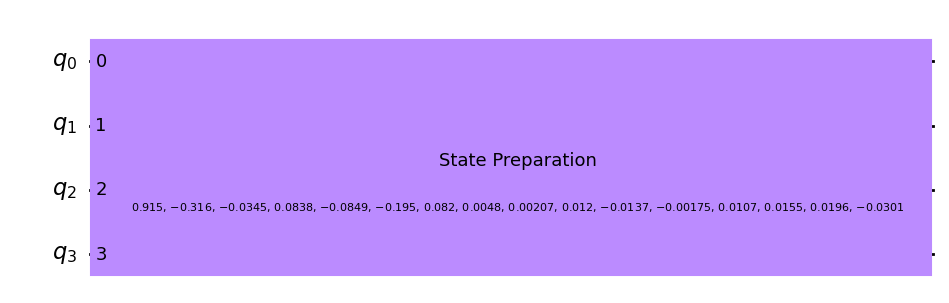

In [30]:
num_qubits = 4
smaple_data = xTrain_norm[0]  
state_prep = StatePreparation(smaple_data)
qc = QuantumCircuit(num_qubits, name="Amplitude encoding")
qc.append(state_prep, range(num_qubits))
qc.draw(output='mpl', style='clifford')

### 5.1 Σχεδιασμός Κβαντικού Μοντέλου (Amplitude VQC Architecture)
---
 Εδώ συνθέτουνε την τλική αρχιτεκτονική του μοντέλου μας αποκλειστικά για Amplitude encoding 4 qubit.
 **Feature Map** (RowFeatureVector): Ένα εξειδικευμένο κύκλωμα του Qiskit που δέχεται 16 χαρακτηριστικά και τα μετατρέπει αυτόματα σε μια κβαντική κατάσταση 4 Qubit.
 **Ansatz** (RealAmplitudes): Το παραμετρικό κυκλωμα που λειτουργεί ως το "νευρωνικό δίκτυο" και θα εκπαιδευτεί. Επειδή έχουμε μόνο 4qubits, θα του δώσουμε μεγαλύτερο βάθος για να έχει περισσότερες παραμέτρους και να μπορεί να μάθει πιο σύνθετα μοτίβα στις επιθέσεις.

Απαιτούμενα Qubits:4
Αριθμός παραμέτρων ansatz: 28


/tmp/ipykernel_55381/3573747456.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_amp=RealAmplitudes(num_qubits=4, reps=2)


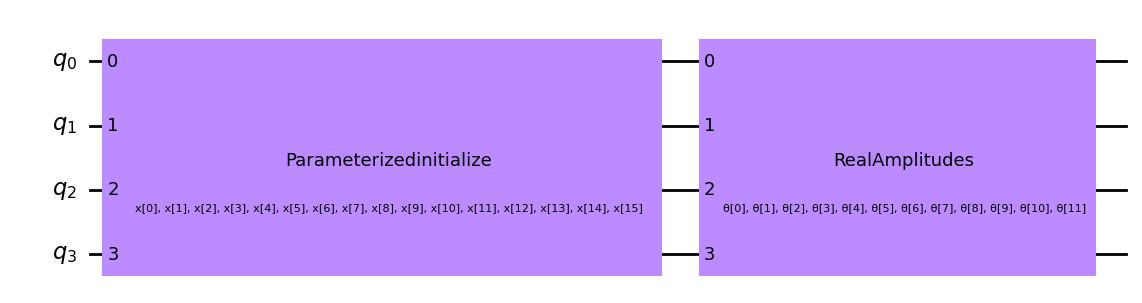

In [31]:
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit.circuit.library import RealAmplitudes

feature_vector_circuit = raw_feature_vector(feature_dimension=16)
ansatz_amp=RealAmplitudes(num_qubits=4, reps=2)
vqc_amp = feature_vector_circuit.compose(ansatz_amp)
print(f'Απαιτούμενα Qubits:{vqc_amp.num_qubits}')
print(f'Αριθμός παραμέτρων ansatz: {vqc_amp.num_parameters}')
vqc_amp.draw(output='mpl', style='clifford')

### 5.2 Επιλογή Optimizer: Γιατί COBYLA;
---
Για να εκπαιδεύσουμε το κβαντικό μας μοντέλο (VQC), χρειαζόμαστε έναν αλγόριθμο βελτιστοποίησης (Optimizer). Ο ρόλος του είναι να βρίσκει τις ιδανικές τιμές για τις άγνωστες γωνίες (τα εκπαιδεύσιμα βάρη $\theta$) του Ansatz, ώστε να ελαχιστοποιείται το σφάλμα (loss) στις προβλέψεις του μοντέλου.

Στο συγκεκριμένο αρχιτεκτονικό σχήμα (Amplitude Encoding), επιλέγουμε τον **COBYLA** (Constrained Optimization BY Linear Approximations) για έναν πολύ συγκεκριμένο, τεχνικό λόγο:

1. **Η "Παγίδα" των Παραγώγων (Gradients):** Οι περισσότεροι κλασικοί optimizers (όπως ο Adam στα Νευρωνικά Δίκτυα) βασίζονται στον υπολογισμό παραγώγων (gradient descent). Χρησιμοποιούν δηλαδή την κλίση της συνάρτησης σφάλματος για να καταλάβουν προς τα πού πρέπει να αλλάξουν τα βάρη. Ωστόσο, η συνάρτηση `raw_feature_vector` που χρησιμοποιούμε, βασίζεται στην κβαντική εντολή `initialize()`. Αυτή η εντολή δεν υποστηρίζει αναλυτική παραγώγιση στο Qiskit. Αν χρησιμοποιούσαμε gradient-based optimizer, η εκπαίδευση θα αποτύγχανε.
2. **Η Λύση του COBYLA (Gradient-Free Optimization):** Ο COBYLA ανήκει στην κατηγορία των *gradient-free* αλγορίθμων, που σημαίνει ότι δεν χρειάζεται να υπολογίσει παραγώγους. 
3. **Πώς λειτουργεί (Η μέθοδος Simplex):** Αντί για παραγώγους, ο COBYLA χτίζει γραμμικές προσεγγίσεις. Δημιουργεί ένα νοητό γεωμετρικό σχήμα (Simplex) στον χώρο των βαρών. Αξιολογεί το σφάλμα στις κορυφές αυτού του σχήματος (κάνοντας δοκιμαστικές εκτελέσεις του κυκλώματος) και "μαντεύει" προς ποια κατεύθυνση βρίσκεται το μικρότερο λάθος. Στη συνέχεια, "μετακινεί" το σχήμα του προς τα εκεί, ενημερώνοντας σταδιακά τα βάρη $\theta$.

Αυτή η μαθηματική προσέγγιση καθιστά τον COBYLA την πιο αξιόπιστη και μονόδρομη επιλογή για κυκλώματα που κάνουν απευθείας State Preparation.

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Ξεκινάει η ΚΑΝΟΝΙΚΗ εκπαίδευση σε 20155 δείγματα...

Η εκπαίδευση ολοκληρώθηκε επιτυχώς σε 156.19 λεπτά!

Το κβαντικό μοντέλο εξετάζει το FULL Test Set...

Συνολική Ακρίβεια (Accuracy): 87.81%

--- Αναλυτική Αναφορά (Classification Report) ---
              precision    recall  f1-score   support

  Normal (0)       0.89      0.88      0.89      2690
  Attack (1)       0.87      0.87      0.87      2347

    accuracy                           0.88      5037
   macro avg       0.88      0.88      0.88      5037
weighted avg       0.88      0.88      0.88      5037



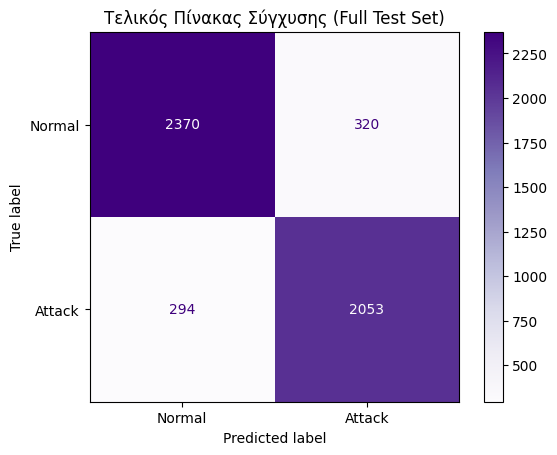

In [155]:
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import time

# 1. ΠΛΗΡΗ ΔΕΔΟΜΕΝΑ ΚΑΙ BINARIZATION (Όλα σε ένα βήμα για να μην έχουμε NameError)
# Αν είναι 'normal' γίνεται 0, αν είναι οτιδήποτε άλλο (επίθεση) γίνεται 1
yTrain_bin = (yTrain != 'normal').astype(int).to_numpy()
yTest_bin = (yTest != 'normal').astype(int).to_numpy()

xTrain_full = xTrain_norm
yTrain_full = yTrain_bin

xTest_full = xTest_norm
yTest_full = yTest_bin

# 2. ΑΥΞΗΣΗ ΒΑΘΟΥΣ ΚΥΚΛΩΜΑΤΟΣ (reps=3 αντί για 2)
feature_vector_circuit = raw_feature_vector(feature_dimension=16)
ansatz_amp = real_amplitudes(num_qubits=4, reps=3)

# 3. ΑΥΞΗΣΗ ΕΠΑΝΑΛΗΨΕΩΝ OPTIMIZER (maxiter=200)
optimizer = COBYLA(maxiter=200)

objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.figure(figsize=(8, 5))
    plt.title("Τελική Εκπαίδευση VQC (Full Dataset - Reps:3)")
    plt.xlabel("Επανάληψη (Iteration)")
    plt.ylabel("Σφάλμα (Objective Function Loss)")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, color='purple', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

vqc_amp_model_final = VQC(
    feature_map=feature_vector_circuit,
    ansatz=ansatz_amp,
    optimizer=optimizer,
    callback=callback_graph
)

# 4. ΤΕΛΙΚΗ ΕΚΠΑΙΔΕΥΣΗ (Θα πάρει αρκετή ώρα!)
print(f"Ξεκινάει η ΚΑΝΟΝΙΚΗ εκπαίδευση σε {len(xTrain_full)} δείγματα...")
start_time = time.time()

vqc_amp_model_final.fit(xTrain_full, yTrain_full)

end_time = time.time()
print(f"\nΗ εκπαίδευση ολοκληρώθηκε επιτυχώς σε {(end_time - start_time)/60:.2f} λεπτά!")

# 5. ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ
print("\nΤο κβαντικό μοντέλο εξετάζει το FULL Test Set...")
y_pred_full = vqc_amp_model_final.predict(xTest_full)
test_score_full = vqc_amp_model_final.score(xTest_full, yTest_full)

print(f"\nΣυνολική Ακρίβεια (Accuracy): {test_score_full * 100:.2f}%\n")
print("--- Αναλυτική Αναφορά (Classification Report) ---")
print(classification_report(yTest_full, y_pred_full, target_names=["Normal (0)", "Attack (1)"]))

# 6. Τελικό Confusion Matrix
cm = confusion_matrix(yTest_full, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap='Purples')
plt.title("Τελικός Πίνακας Σύγχυσης (Full Test Set)")
plt.show()

In [32]:
# Αποθήκευση του εκπαιδευμένου μοντέλου στο φάκελο που βρίσκεσαι
vqc_amp_model_final.save("vqc_model_200_samples.model")

print("Το μοντέλο αποθηκεύτηκε επιτυχώς στο αρχείο: vqc_model_200_samples.model")

NameError: name 'vqc_amp_model_final' is not defined

__5.3 Ιεραρχική Ταξινόμηση: Ομαδοποίηση Επιθέσεων (Multiclass Classification)__

Για την πλήρη ανάλυση των απειλών, υλοποιείται μια ιεραρχική αρχιτεκτονική (Cascade Classifier). Αφού το πρώτο μοντέλο VQC (Φύλακας) διαχωρίσει την κανονική κίνηση από τις επιθέσεις, ένα δεύτερο, εξειδικευμένο μοντέλο VQC (Ανακριτής) αναλαμβάνει την κατηγοριοποίηση της εκάστοτε επίθεσης. 

Λόγω του μεγάλου πλήθους (22) και της σπανιότητας ορισμένων επιθέσεων στο NSL-KDD, εφαρμόζεται η καθιερωμένη στη βιβλιογραφία ομαδοποίηση σε 4 κύριες κλάσεις:
1. **DoS (Denial of Service) [0]:** Εξάντληση πόρων (π.χ. neptune, smurf).
2. **Probe (Αναγνώριση) [1]:** Σάρωση συστημάτων (π.χ. satan, portsweep).
3. **R2L (Remote to Local) [2]:** Μη εξουσιοδοτημένη πρόσβαση (π.χ. guess_passwd).
4. **U2R (User to Root) [3]:** Κλιμάκωση προνομίων (π.χ. buffer_overflow).

Το Training Set φιλτράρεται ώστε να περιέχει *αποκλειστικά* κακόβουλη κίνηση, και τα string labels αντιστοιχίζονται στους ακέραιους $0, 1, 2, 3$ για την εκπαίδευση του πολυταξικού κβαντικού ταξινομητή.

In [33]:
import numpy as np
import pandas as pd

# 1. Το Επίσημο Λεξικό Ομαδοποίησης του NSL-KDD
attack_mapping = {
    # DoS (Κλάση 0)
    'back': 0, 'land': 0, 'neptune': 0, 'pod': 0, 'smurf': 0, 'teardrop': 0, 'apache2': 0, 'udpstorm': 0, 'processtable': 0, 'worm': 0, 'mailbomb': 0,
    # Probe (Κλάση 1)
    'satan': 1, 'ipsweep': 1, 'nmap': 1, 'portsweep': 1, 'mscan': 1, 'saint': 1,
    # R2L (Κλάση 2)
    'guess_passwd': 2, 'ftp_write': 2, 'imap': 2, 'phf': 2, 'multihop': 2, 'warezmaster': 2, 'warezclient': 2, 'spy': 2, 'xlock': 2, 'xsnoop': 2, 'snmpguess': 2, 'snmpgetattack': 2, 'httptunnel': 2, 'sendmail': 2, 'named': 2,
    # U2R (Κλάση 3)
    'buffer_overflow': 3, 'loadmodule': 3, 'rootkit': 3, 'perl': 3, 'sqlattack': 3, 'xterm': 3, 'ps': 3
}

# 2. Μετατρέπουμε τα labels σε NumPy arrays για να μην έχουμε ποτέ ξανά Pandas Index Error
yTrain_np = np.array(yTrain)
yTest_np = np.array(yTest)

# 3. BOOLEAN MASKS: Φτιάχνουμε μια "μάσκα" που είναι True μόνο για τις επιθέσεις
train_attack_mask = (yTrain_np != 'normal')
test_attack_mask = (yTest_np != 'normal')

# 4. Εφαρμόζουμε τη μάσκα για να κρατήσουμε ΜΟΝΟ τις επιθέσεις (X και Y)
xTrain_attacks_only = xTrain_norm[train_attack_mask]
yTrain_attacks_str = yTrain_np[train_attack_mask]

xTest_attacks_only = xTest_norm[test_attack_mask]
yTest_attacks_str = yTest_np[test_attack_mask]

# 5. Αντικαθιστούμε τις λέξεις με αριθμούς (0, 1, 2, 3) χρησιμοποιώντας το λεξικό
yTrain_multiclass = np.array([attack_mapping[attack] for attack in yTrain_attacks_str])
yTest_multiclass = np.array([attack_mapping[attack] for attack in yTest_attacks_str])

print(f"Αρχικό σύνολο εγγραφών εκπαίδευσης (μαζί με normal): {len(xTrain_norm)}")
print(f"Νέο σύνολο (ΜΟΝΟ επιθέσεις) για τον Ανακριτή: {len(xTrain_attacks_only)}")

# Κατανομή των 4 Κατηγοριών
unique, counts = np.unique(yTrain_multiclass, return_counts=True)
category_names = ['DoS (0)', 'Probe (1)', 'R2L (2)', 'U2R (3)']

print("\n--- Κατανομή των 4 Κατηγοριών στο Νέο Training Set ---")
for u, c in zip(unique, counts):
    print(f"{category_names[u]}: {c} εγγραφές")

Αρχικό σύνολο εγγραφών εκπαίδευσης (μαζί με normal): 20155
Νέο σύνολο (ΜΟΝΟ επιθέσεις) για τον Ανακριτή: 9396

--- Κατανομή των 4 Κατηγοριών στο Νέο Training Set ---
DoS (0): 7386 εγγραφές
Probe (1): 1832 εγγραφές
R2L (2): 168 εγγραφές
U2R (3): 10 εγγραφές


In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import normalize, OneHotEncoder
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import time

# 1. SMOTE: Δημιουργία Συνθετικών Δεδομένων
print("Εφαρμογή SMOTE...")
smote = SMOTE(random_state=42)
xTrain_smote_raw, yTrain_smote = smote.fit_resample(xTrain_attacks_only, yTrain_multiclass)

# 2. ΤΟ ΚΡΙΣΙΜΟ ΒΗΜΑ: Επανα-κανονικοποίηση (L2) μετά τον SMOTE!
print("Επανα-κανονικοποίηση (L2 Norm) των συνθετικών δεδομένων...")
xTrain_smote_norm = normalize(xTrain_smote_raw, norm='l2', axis=1)

# 3. ΓΡΗΓΟΡΟ ΥΠΟΣΥΝΟΛΟ (Subsampling) για το Test (250 από κάθε κλάση = 1000 σύνολο)
np.random.seed(42)
sample_indices = []
for i in range(4): # Για κάθε κλάση 0, 1, 2, 3
    idx = np.where(yTrain_smote == i)[0]
    # Παίρνουμε 250 τυχαίες εγγραφές από την κάθε κλάση
    idx_sampled = np.random.choice(idx, 250, replace=False)
    sample_indices.extend(idx_sampled)

# Ανακατεύουμε τα επιλεγμένα δείγματα
np.random.shuffle(sample_indices)
xTrain_fast = xTrain_smote_norm[sample_indices]
yTrain_fast = yTrain_smote[sample_indices]

print(f"Τελικό Training Set για το Γρήγορο Τεστ: {len(xTrain_fast)} εγγραφές.")

# 4. ONE-HOT ENCODING
encoder = OneHotEncoder(sparse_output=False)
yTrain_onehot = encoder.fit_transform(yTrain_fast.reshape(-1, 1))

# Προετοιμασία Test Set (Δοκιμάζουμε σε 400 άγνωστες επιθέσεις)
test_sample_size = min(400, len(xTest_attacks_only))
xTest_multi_sample = xTest_attacks_only[:test_sample_size]
yTest_multi_sample = yTest_multiclass[:test_sample_size]
yTest_onehot = encoder.transform(yTest_multi_sample.reshape(-1, 1))

# 5. ΣΤΗΣΙΜΟ VQC (Λίγο πιο βαθύ, αλλά γρήγορο)
feature_map_multi = raw_feature_vector(feature_dimension=16)
ansatz_multi = real_amplitudes(num_qubits=4, reps=5)
optimizer_multi = COBYLA(maxiter=150) # 150 για να δούμε γρήγορα τάση

objective_func_vals = []
def callback_graph_multi(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.figure(figsize=(8, 5))
    plt.title("Γρήγορο Τεστ Ανακριτή (SMOTE + L2 + Subsample)")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, color='orange', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

vqc_test_model = VQC(
    feature_map=feature_map_multi,
    ansatz=ansatz_multi,
    optimizer=optimizer_multi,
    callback=callback_graph_multi
)

# 6. ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΑΞΙΟΛΟΓΗΣΗ
print("Ξεκινάει η γρήγορη εκπαίδευση...")
start_time = time.time()
vqc_test_model.fit(xTrain_fast, yTrain_onehot)
end_time = time.time()
print(f"\nΗ εκπαίδευση ολοκληρώθηκε σε {(end_time - start_time)/60:.2f} λεπτά!")

print("\nΑξιολόγηση στο Test Set...")
y_pred_onehot = vqc_test_model.predict(xTest_multi_sample)
y_pred_classes = np.argmax(y_pred_onehot, axis=1)

print("\n--- Αναλυτική Αναφορά ---")
print(classification_report(yTest_multi_sample, y_pred_classes, target_names=['DoS (0)', 'Probe (1)', 'R2L (2)', 'U2R (3)'], zero_division=0))

cm = confusion_matrix(yTest_multi_sample, y_pred_classes, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DoS', 'Probe', 'R2L', 'U2R'])
disp.plot(cmap='Oranges')
plt.title("Πίνακας Σύγχυσης (Γρήγορο Τεστ)")
plt.show()

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Εφαρμογή SMOTE...
Επανα-κανονικοποίηση (L2 Norm) των συνθετικών δεδομένων...
Τελικό Training Set για το Γρήγορο Τεστ: 1000 εγγραφές.
Ξεκινάει η γρήγορη εκπαίδευση...

Η εκπαίδευση ολοκληρώθηκε σε 6.81 λεπτά!

Αξιολόγηση στο Test Set...

--- Αναλυτική Αναφορά ---


ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter


--- Αναλυτική Αναφορά (Διορθωμένη) ---
              precision    recall  f1-score   support

     DoS (0)       0.96      0.97      0.97       320
   Probe (1)       0.85      0.86      0.86        73
     R2L (2)       0.00      0.00      0.00         7
     U2R (3)       0.00      0.00      0.00         0

    accuracy                           0.94       400
   macro avg       0.45      0.46      0.46       400
weighted avg       0.92      0.94      0.93       400



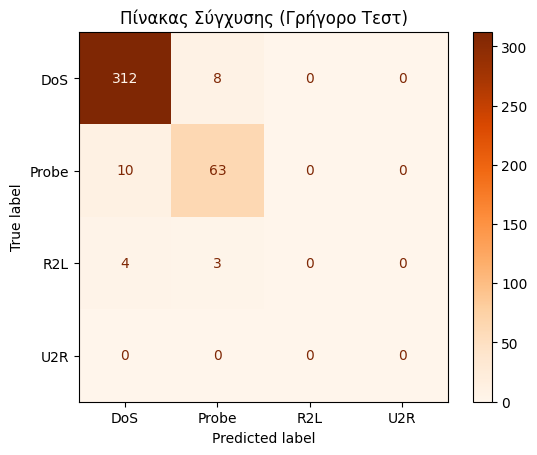

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Το μοντέλο είναι ήδη εκπαιδευμένο, απλά τυπώνουμε τα αποτελέσματα!
print("\n--- Αναλυτική Αναφορά (Διορθωμένη) ---")
print(classification_report(
    yTest_multi_sample, 
    y_pred_classes, 
    labels=[0, 1, 2, 3], # ΑΥΤΟ ΕΛΕΙΠΕ: Λέμε στην Python να περιμένει 4 κλάσεις ακόμα κι αν λείπει κάποια
    target_names=['DoS (0)', 'Probe (1)', 'R2L (2)', 'U2R (3)'], 
    zero_division=0
))

# Ζωγραφίζουμε ξανά το Matrix
cm = confusion_matrix(yTest_multi_sample, y_pred_classes, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DoS', 'Probe', 'R2L', 'U2R'])
disp.plot(cmap='Oranges')
plt.title("Πίνακας Σύγχυσης (Γρήγορο Τεστ)")
plt.show()